# EDA – Apartment Transaction Price

### 목적
- 데이터 구조 이해
- 이상치/왜곡/도메인 신호 식별
- Feature Engineering 의사결정 근거 확보
  

### 1. 환경 설정

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from lab_core.util.path import raw_data_dir, ext_data_dir, eda_out_dir
from lab_core.util.time_ids import make_run_id
from lab_core.styles.viz import setup_global
from lab_core.hyj.data.clieaning import rename_columns, drop_high_missing
from lab_core.hyj.data.data_split import concat_with_split_flag
from lab_core.hyj.eda.eda_missing import missing_eda_report
from lab_core.hyj.eda.eda_outlier import outlier_eda_report

setup_global()

### 2. 데이터 로딩 & 기본 구조 파악

In [3]:
train_path = raw_data_dir("train.csv")
test_path = raw_data_dir("test.csv")

train = pd.read_csv(train_path)
x_train = train.drop("target", axis=1)
y_train = train["target"]
test = pd.read_csv(test_path)

/tmp/ipykernel_737320/2159516469.py:4: DtypeWarning: Columns (16,17,36) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(train_path)


In [4]:

# Train data와 Test data shape은 아래와 같습니다.
print('Train data shape : ', train.shape, 'Test data shape : ', test.shape)

Train data shape :  (1118822, 52) Test data shape :  (9272, 51)


In [5]:
train.head()

,시군구,번지,본번,부번,아파트명,전용면적(㎡),계약년월,계약일,층,건축년도,...,건축면적,주차대수,기타/의무/임대/임의=1/2/3/4,단지승인일,사용허가여부,관리비 업로드,좌표X,좌표Y,단지신청일,target
0,서울특별시 강남구 개포동,658-1,658.0,1.0,개포6차우성,79.97,201712,8,3,1987,...,4858.0,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,124000
1,서울특별시 강남구 개포동,658-1,658.0,1.0,개포6차우성,79.97,201712,22,4,1987,...,4858.0,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,123500
2,서울특별시 강남구 개포동,658-1,658.0,1.0,개포6차우성,54.98,201712,28,5,1987,...,4858.0,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,91500
3,서울특별시 강남구 개포동,658-1,658.0,1.0,개포6차우성,79.97,201801,3,4,1987,...,4858.0,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,130000
4,서울특별시 강남구 개포동,658-1,658.0,1.0,개포6차우성,79.97,201801,8,2,1987,...,4858.0,262.0,임의,2022-11-17 13:00:29.0,Y,N,127.05721,37.476763,2022-11-17 10:19:06.0,117000


In [8]:
train.dtypes

시군구                        object
번지                         object
본번                        float64
부번                        float64
아파트명                       object
전용면적(㎡)                   float64
계약년월                        int64
계약일                         int64
층                           int64
건축년도                        int64
도로명                        object
해제사유발생일                   float64
등기신청일자                     object
거래유형                       object
중개사소재지                     object
k-단지분류(아파트,주상복합등등)         object
k-전화번호                     object
k-팩스번호                     object
단지소개기존clob                float64
k-세대타입(분양형태)               object
k-관리방식                     object
k-복도유형                     object
k-난방방식                     object
k-전체동수                    float64
k-전체세대수                   float64
k-건설사(시공사)                 object
k-시행사                      object
k-사용검사일-사용승인일              object
k-연면적                     float64
k-주거전용면적      

### 3. 데이터 전처리

- 모델링 전에 데이터 내 결측치, 이상치 등을 처리
- 용이한 전처리를 위해 train과 test data를 합친 하나의 데이터로 진행

##### 3.1. concat_with_split_flat 함수
1. flag_col에 지정된 값으로 train, test 셋에 컬럼을 추가 합니다.
   - train_value, test_value 기본 값 = (0, 1)
2. 데이터 셋을 합치기 전 검증을 수행합니다. (validate 값이 True일 때)
   - 두 데이터 셋의 컬럼 구성이 동일한지 여부.
3. 두 데이터셋을 합칩니다. 
   - axis 디폴트 값 = 0
   - ignore_index 디폴트 값 = True (합치고 index 재생성)
   - sort 디폴트 값 = False

In [6]:
concat_info = concat_with_split_flag(x_train, test, flag_col="is_test")

all_data = concat_info.data
all_data[concat_info.flag_col].value_counts()

is_test
0    1118822
1       9272
Name: count, dtype: int64

##### 3.2. rename_columns 함수

- 컬럼명을 Mapping 값으로 변경합니다.
   - 알아보기 불편한 컬럼을 단순화 시키기.
   - 다른 데이터 셋과의 병합을 위해 통일 시키기. 
   - inplace 디폴트 값 = False

In [7]:
# 컬럼명을 쉽게 변경
COLUMN_MAP = {
    "전용면적(㎡)": "전용면적",
    "k-단지분류(아파트,주상복합등등)": "k-단지분류",
    "기타/의무/임대/임의=1/2/3/4": "기타/의무/임대/임의",
}

all_data = rename_columns(all_data, COLUMN_MAP)

### 3.3 drop_high_missing 함수
- 결측치 개수가 임계값 이상인 컬럼을 제거합니다.
- 반환 값 (Tuple)
  - df_clean : 결측치 많은 컬럼이 제거된 데이터
  - summary : 제거된 컬럼 요약 정보

In [8]:
# 결측치 100만 개 이상인 컬럼 제거
df_clean, summary = drop_high_missing(all_data, 1_000_000)
display(summary)

해제사유발생일       1121899
단지소개기존clob    1058958
k-135㎡초과      1127765
k-홈페이지        1013523
k-등록일자        1116386
dtype: int64

### 4. EDA Report

In [9]:
# 리포트 저장소 준비

eda_data = df_clean
eda_id = make_run_id("hyj", mid_id="eda")
eda_path = eda_out_dir(eda_id)

##### 4.1 결측치 리포트

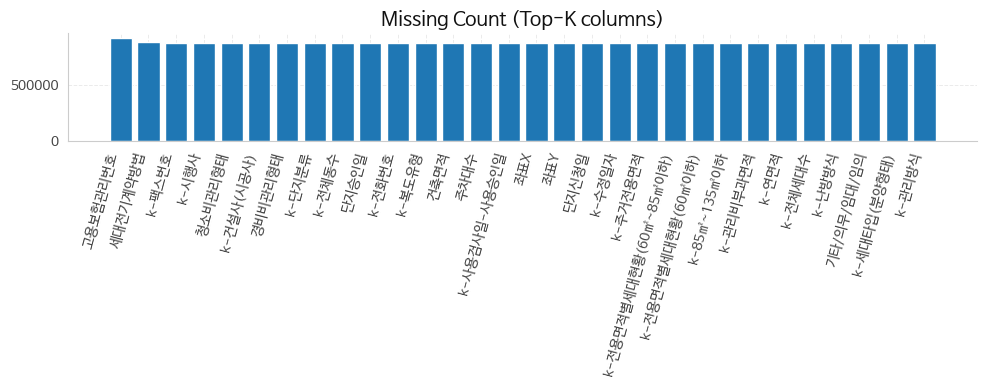

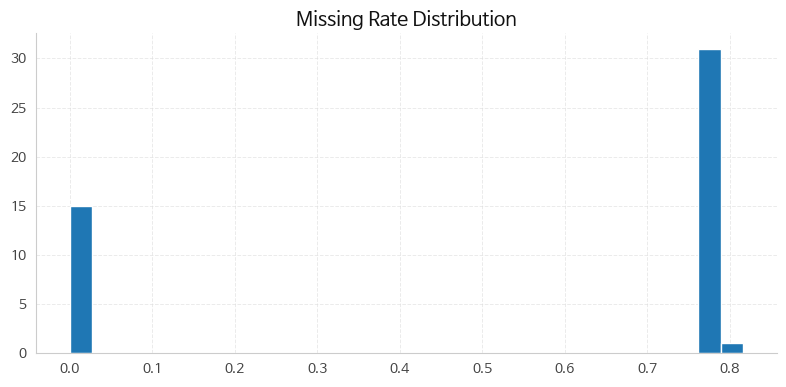

In [10]:
# eda_missing = missing_eda_report(eda_data, save_path=eda_path)
# eda_missing = missing_eda_report(eda_data, token_match_mode="exact")
eda_missing = missing_eda_report(eda_data, token_match_mode="startswith")
# eda_missing = missing_eda_report(eda_data, token_match_mode="endswith")

- 결측치 개요

In [11]:
display(eda_missing.summary)

,dtype,n_rows,na_cnt,na_rate,non_na_cnt,nunique,top_values
고용보험관리번호,object,1128094,920757,0.816206,207337,526,'909-01-23103-1':3068; '21380014370':2816; '90...
세대전기계약방법,object,1128094,885389,0.784854,242705,2,'종합계약':124610; '단일계약':118095
k-팩스번호,object,1128094,879348,0.779499,248746,1385,'02-572-3212':2816; 24162280.0:2470; '02561314...
k-시행사,object,1128094,877834,0.778157,250260,556,'SH공사':12604; '대한주택공사':7784; '도시개발공사':4284; 's...
청소비관리형태,object,1128094,877751,0.778083,250343,4,'위탁':227511; '직영':15174; '위탁+직영':4179; '기타':3479
k-건설사(시공사),object,1128094,877637,0.777982,250457,344,'삼성물산':14259; '대우건설':11549; '현대건설':10575; '대한주...
경비비관리형태,object,1128094,877561,0.777915,250533,4,'위탁':208757; '직영':33791; '위탁+직영':6168; '기타':1817
k-단지분류,object,1128094,877273,0.777659,250821,5,'아파트':238586; '주상복합':11450; '도시형 생활주택(주상복합)':5...
k-전체동수,float64,1128094,877207,0.777601,250887,41,10.0:20021; 2.0:17300; 6.0:16357; 3.0:15418; 4...
단지승인일,object,1128094,876854,0.777288,251240,736,'2013-06-23 12:47:34.0':3068; '2013-06-23 14:2...


- 범주형 토큰 분석 

In [12]:
display(eda_missing.token_hits)

,col,value,count,matched_tokens
0,k-시행사,모름,102,모름


##### 4.2 이상치 리포트

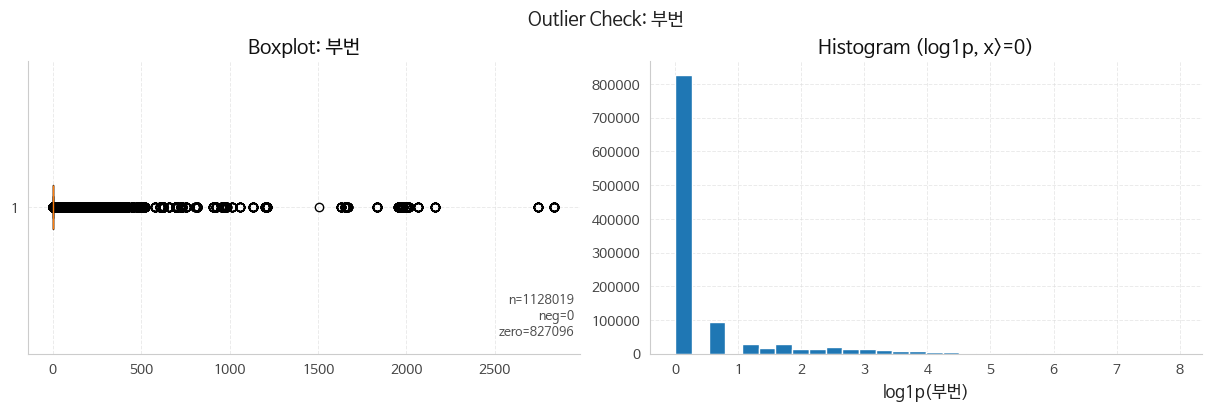

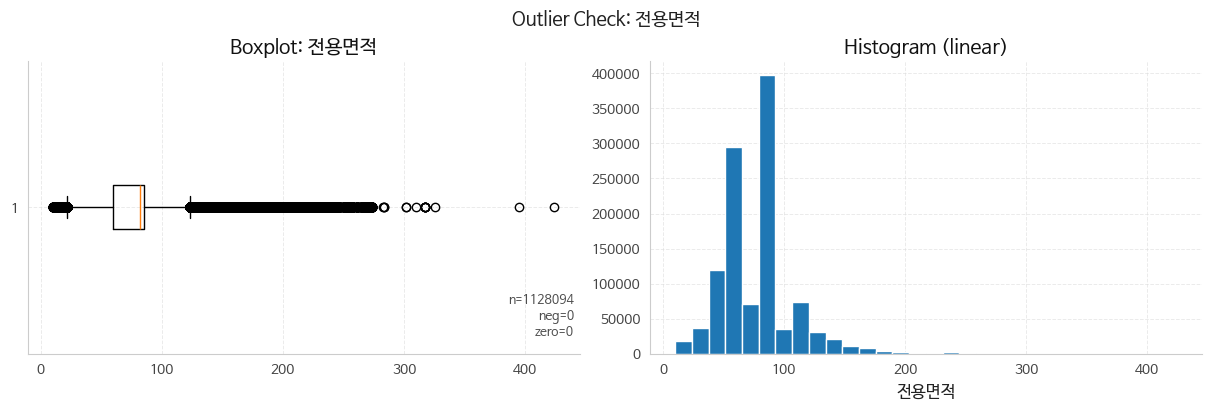

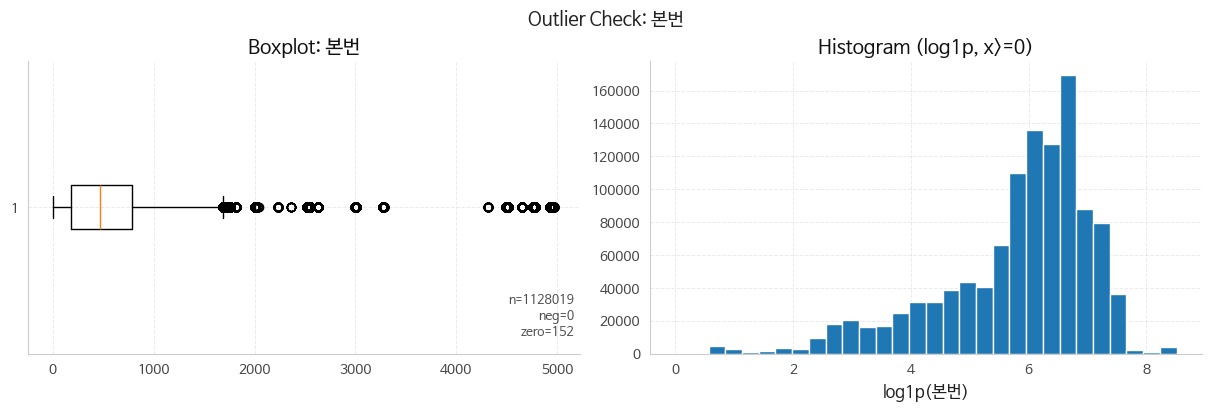

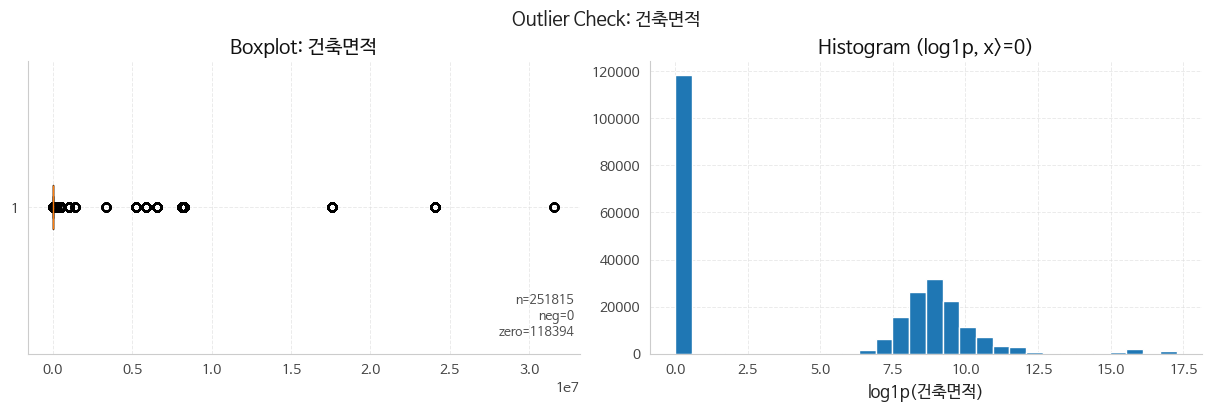

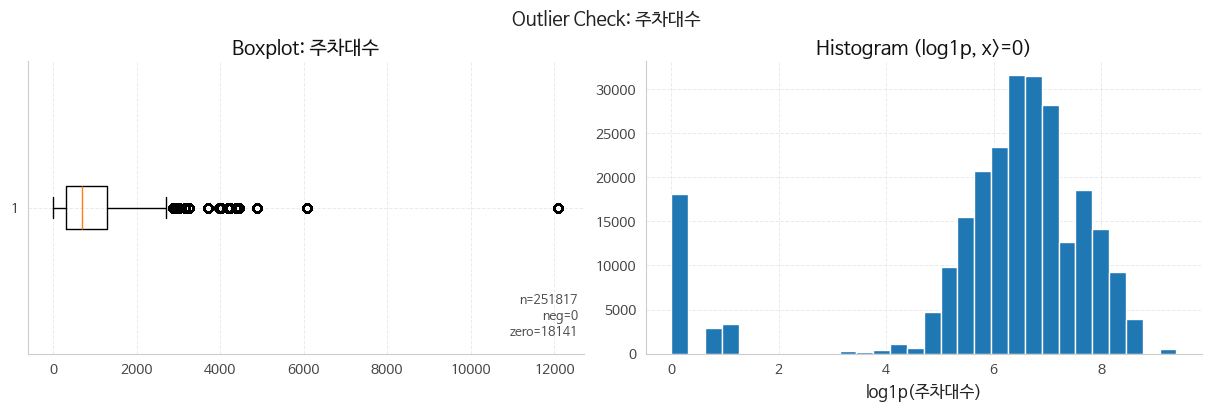

In [13]:
# 이상치 리포트
eda_outlier = outlier_eda_report(eda_data, save_path=eda_path)

- 범주형 이상치 개요

In [14]:
display(eda_outlier.categorical_summary)

,dtype,n_non_na,rule,min_count,outlier_cnt,outlier_rate,outlier_low_cnt,outlier_high_cnt
col,,,,,,,,
k-팩스번호,object,248746,RARE,3,30,0.000121,0,0
아파트명,object,1125958,RARE,3,30,0.000027,0,0
번지,object,1127867,RARE,3,30,0.000027,0,0
도로명,object,1128094,RARE,3,30,0.000027,0,0
중개사소재지,object,1128094,RARE,3,30,0.000027,0,0
k-전화번호,object,251244,RARE,3,18,0.000072,0,0
단지승인일,object,251240,RARE,3,8,0.000032,0,0
k-수정일자,object,251924,RARE,3,8,0.000032,0,0
k-사용검사일-사용승인일,object,251835,RARE,3,7,0.000028,0,0


- 수치형 이상치 개요

In [15]:
display(eda_outlier.numeric_summary)

,dtype,n_non_na,rule,k,outlier_cnt,outlier_rate,outlier_low_cnt,outlier_high_cnt,iqr,iqr_lo,iqr_hi,min,median,max
col,,,,,,,,,,,,,,
부번,float64,1128019,IQR,1.5,177365,0.157236,0,177365,1.000000,-1.500000,2.500000,0.000000,0.000000,2.837000e+03
전용면적,float64,1128094,IQR,1.5,90053,0.079828,16645,73408,25.310000,21.685000,122.925000,10.020000,81.870000,4.243200e+02
본번,float64,1128019,IQR,1.5,33984,0.030127,0,33984,604.000000,-729.000000,1687.000000,0.000000,471.000000,4.974000e+03
건축면적,float64,251815,IQR,1.5,23037,0.091484,0,23037,8414.210000,-12621.315000,21035.525000,0.000000,1735.000000,3.159620e+07
주차대수,float64,251817,IQR,1.5,21426,0.085086,0,21426,968.000000,-1136.000000,2736.000000,0.000000,683.000000,1.209600e+04
k-연면적,float64,251969,IQR,1.5,19782,0.078510,0,19782,150238.000000,-171691.000000,429261.000000,0.000000,102624.000000,9.591851e+06
k-전용면적별세대현황(60㎡이하),float64,251924,IQR,1.5,19713,0.078250,0,19713,528.000000,-744.000000,1368.000000,0.000000,226.000000,4.975000e+03
k-주거전용면적,float64,251924,IQR,1.5,18758,0.074459,0,18758,85106.000000,-95679.000000,244745.000000,2338.000000,60505.000000,7.347810e+05
k-전용면적별세대현황(60㎡~85㎡이하),float64,251924,IQR,1.5,17589,0.069819,0,17589,487.000000,-635.500000,1312.500000,0.000000,258.000000,5.132000e+03


- 이상치 상세

In [16]:
display(eda_outlier.outliers)

,col,row_index,value,rule,side,detail
0,번지,2029,919-3,RARE,rare,"count=1, min_count=3"
1,번지,26377,779-37,RARE,rare,"count=1, min_count=3"
2,번지,53624,495-3,RARE,rare,"count=1, min_count=3"
3,번지,61332,8-27,RARE,rare,"count=1, min_count=3"
4,번지,88701,89-258,RARE,rare,"count=1, min_count=3"
...,...,...,...,...,...,...
956,단지신청일,211177,2021-12-01 11:09:41.0,RARE,rare,"count=2, min_count=3"
957,단지신청일,217470,2021-11-10 14:47:30.0,RARE,rare,"count=2, min_count=3"
958,단지신청일,219825,2022-12-12 11:52:27.0,RARE,rare,"count=2, min_count=3"
959,단지신청일,219881,2022-08-11 16:36:06.0,RARE,rare,"count=2, min_count=3"
